### Gruppenmitglieder:
- brni1027
- obha1011

# Aufgabe 1
## a)

In [31]:
import pandas as pd
import numpy as np

In [32]:
df = pd.read_csv(r'C:\Users\Hagen\OneDrive\HKA\SS26\Umweltmonitoring\Preisach (Mi)\Arbeitsblätter\AB3\Umweltmonitoring-AB3\co2_mlo_surface-flask_1_ccgg_event.txt', 
                  sep=' ',          # Trennzeichen
                  comment='#',       # Kommentarzeilen ignorieren
                  decimal='.')       # Dezimaltrennzeichen

df.info()
df.describe()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10940 entries, 0 to 10939
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   site_code                10940 non-null  object 
 1   year                     10940 non-null  int64  
 2   month                    10940 non-null  int64  
 3   day                      10940 non-null  int64  
 4   hour                     10940 non-null  int64  
 5   minute                   10940 non-null  int64  
 6   second                   10940 non-null  int64  
 7   datetime                 10940 non-null  object 
 8   time_decimal             10940 non-null  float64
 9   air_sample_container_id  10940 non-null  object 
 10  value                    10940 non-null  float64
 11  value_unc                10940 non-null  float64
 12  latitude                 10940 non-null  float64
 13  longitude                10940 non-null  float64
 14  altitude              

,site_code,year,month,day,hour,minute,second,datetime,time_decimal,air_sample_container_id,...,latitude,longitude,altitude,elevation,intake_height,method,event_number,instrument,analysis_datetime,qcflag
0,MLO,1969,8,20,17,55,0,1969-08-20T17:55:00Z,1969.634922,33-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78808,LR1,1969-09-09T09:02:00,...
1,MLO,1969,8,20,17,55,0,1969-08-20T17:55:00Z,1969.634922,34-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78809,LR1,1969-09-09T09:12:00,C..
2,MLO,1969,8,20,18,30,0,1969-08-20T18:30:00Z,1969.634989,31-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78810,LR1,1969-09-09T08:58:00,M..
3,MLO,1969,8,20,18,30,0,1969-08-20T18:30:00Z,1969.634989,32-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78811,LR1,1969-09-09T09:00:00,M..
4,MLO,1969,8,27,19,15,0,1969-08-27T19:15:00Z,1969.654252,35-69,...,19.5300,-155.5800,3399.0,3397.0,2.0,N,78812,LR1,1969-09-09T08:42:00,M..
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10935,MLO,2024,12,24,19,17,0,2024-12-24T19:17:00Z,2024.980337,2242-99,...,19.5362,-155.5763,3437.0,3397.0,40.0,S,545830,PIC-032,2025-03-20T12:14:29,...
10936,MLO,2024,12,31,19,40,0,2024-12-31T19:40:00Z,2024.999507,1282-99,...,19.5362,-155.5763,3402.0,3397.0,5.0,P,547491,PIC-032,2025-03-21T14:19:50,...
10937,MLO,2024,12,31,19,40,0,2024-12-31T19:40:00Z,2024.999507,5182-99,...,19.5362,-155.5763,3402.0,3397.0,5.0,P,547492,PIC-032,2025-03-21T14:34:17,...
10938,MLO,2024,12,31,19,43,0,2024-12-31T19:43:00Z,2024.999512,2683-99,...,19.5362,-155.5763,3437.0,3397.0,40.0,S,547489,PIC-032,2025-03-21T15:17:33,...


In [33]:
if 'datetime' not in df.columns and df.index.name == 'datetime':
    df = df.reset_index()

df['datetime'] = pd.to_datetime(df['datetime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10940 entries, 0 to 10939
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   site_code                10940 non-null  object             
 1   year                     10940 non-null  int64              
 2   month                    10940 non-null  int64              
 3   day                      10940 non-null  int64              
 4   hour                     10940 non-null  int64              
 5   minute                   10940 non-null  int64              
 6   second                   10940 non-null  int64              
 7   datetime                 10940 non-null  datetime64[ns, UTC]
 8   time_decimal             10940 non-null  float64            
 9   air_sample_container_id  10940 non-null  object             
 10  value                    10940 non-null  float64            
 11  value_unc                109

In [37]:
# Datenbereinigung: Platzhalterwerte und Qualitätsfilter
df_clean = df.copy()

# NOAA-Platzhalter für ungültige CO2-Werte zu NaN machen (numerischer Typ bleibt erhalten)
df_clean['value'] = df_clean['value'].replace(-999.99, np.nan)

# Nur qualitativ unauffällige Messungen behalten
if 'qcflag' in df_clean.columns:
    df_clean = df_clean[df_clean['qcflag'] == '...'].copy()

# Zeilen ohne gültigen CO2-Wert entfernen
df_clean = df_clean.dropna(subset=['value'])

# Kurzer Qualitäts-Check
print('Originale Zeilen:', len(df))
print('Bereinigte Zeilen:', len(df_clean))
print('Entfernte Zeilen:', len(df) - len(df_clean))
print('\nSummary Statistics (CO2-Statistik nach Bereinigung):')
print(df_clean['value'].describe())

Originale Zeilen: 10940
Bereinigte Zeilen: 9913
Entfernte Zeilen: 1027

Summary Statistics (CO2-Statistik nach Bereinigung):
count    9913.000000
mean      372.876171
std        25.796180
min       320.230000
25%       351.080000
50%       368.700000
75%       393.560000
max       427.760000
Name: value, dtype: float64


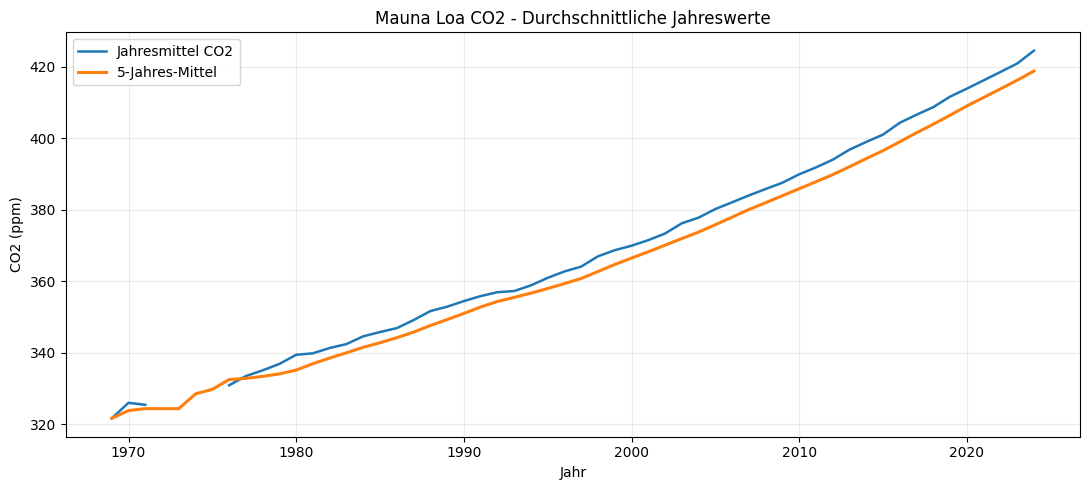

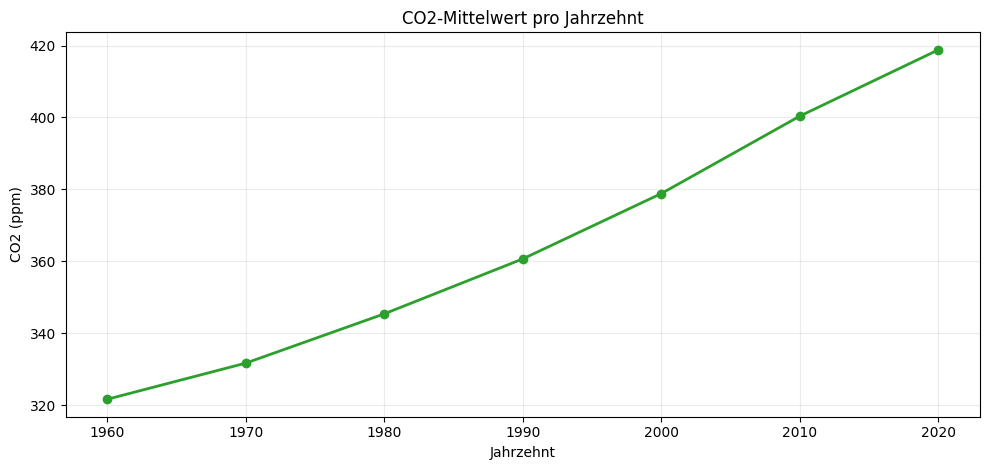

In [38]:
import matplotlib.pyplot as plt

# Sicherstellen, dass datetime als DatetimeIndex vorliegt
if not isinstance(df_clean.index, pd.DatetimeIndex):
    if 'datetime' in df_clean.columns:
        df_clean['datetime'] = pd.to_datetime(df_clean['datetime'], errors='coerce')
        df_clean = df_clean.dropna(subset=['datetime']).set_index('datetime')

# 1) Durchschnittliche Jahreswerte (Liniengraph)
annual_mean = df_clean['value'].resample('YE').mean()
annual_mean.index = annual_mean.index.year

plt.figure(figsize=(11, 5))
plt.plot(annual_mean.index, annual_mean.values, color='tab:blue', linewidth=1.8, label='Jahresmittel CO2')
plt.plot(annual_mean.index, annual_mean.rolling(5, min_periods=1).mean(),
         color='tab:orange', linewidth=2.2, label='5-Jahres-Mittel')
plt.title('Mauna Loa CO2 - Durchschnittliche Jahreswerte')
plt.xlabel('Jahr')
plt.ylabel('CO2 (ppm)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Dekaden-Mittelwerte
annual_df = annual_mean.reset_index()
annual_df.columns = ['year', 'co2_mean']
annual_df['decade'] = (annual_df['year'] // 10) * 10

decade_mean = annual_df.groupby('decade', as_index=False)['co2_mean'].mean()

plt.figure(figsize=(10, 4.8))
plt.plot(decade_mean['decade'], decade_mean['co2_mean'], marker='o', linewidth=2, color='tab:green')
plt.title('CO2-Mittelwert pro Jahrzehnt')
plt.xlabel('Jahrzehnt')
plt.ylabel('CO2 (ppm)')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## b)